In [38]:
import pandas as pd

In [39]:
ratings = pd.read_csv("ratings.csv")   
movies  = pd.read_csv("movies.csv")   
links   = pd.read_csv("links.csv")

In [40]:
ratings_movies = ratings.merge(movies, on="movieId", how="left")

In [41]:
df = ratings.merge(movies, on="movieId", how="left")

In [42]:
df = df.drop(columns=["timestamp"])

In [43]:
print(df.head())
df.to_csv("joined_data.csv", index=False)

   userId  movieId  rating                        title  \
0       1        1     4.0             Toy Story (1995)   
1       1        3     4.0      Grumpier Old Men (1995)   
2       1        6     4.0                  Heat (1995)   
3       1       47     5.0  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  


In [44]:
print(df)

        userId  movieId  rating                           title  \
0            1        1     4.0                Toy Story (1995)   
1            1        3     4.0         Grumpier Old Men (1995)   
2            1        6     4.0                     Heat (1995)   
3            1       47     5.0     Seven (a.k.a. Se7en) (1995)   
4            1       50     5.0      Usual Suspects, The (1995)   
...        ...      ...     ...                             ...   
100831     610   166534     4.0                    Split (2017)   
100832     610   168248     5.0   John Wick: Chapter Two (2017)   
100833     610   168250     5.0                  Get Out (2017)   
100834     610   168252     5.0                    Logan (2017)   
100835     610   170875     3.0  The Fate of the Furious (2017)   

                                             genres  
0       Adventure|Animation|Children|Comedy|Fantasy  
1                                    Comedy|Romance  
2                             Act

In [45]:
df.head()

,userId,movieId,rating,title,genres
0,1,1,4.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [46]:
df.tail()

,userId,movieId,rating,title,genres
100831,610,166534,4.0,Split (2017),Drama|Horror|Thriller
100832,610,168248,5.0,John Wick: Chapter Two (2017),Action|Crime|Thriller
100833,610,168250,5.0,Get Out (2017),Horror
100834,610,168252,5.0,Logan (2017),Action|Sci-Fi
100835,610,170875,3.0,The Fate of the Furious (2017),Action|Crime|Drama|Thriller


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   userId   100836 non-null  int64  
 1   movieId  100836 non-null  int64  
 2   rating   100836 non-null  float64
 3   title    100836 non-null  object 
 4   genres   100836 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 3.8+ MB


In [48]:

df.index

RangeIndex(start=0, stop=100836, step=1)

In [49]:
print(df.shape) 

(100836, 5)


In [50]:
print(df.columns) 

Index(['userId', 'movieId', 'rating', 'title', 'genres'], dtype='object')


In [51]:
df.isnull().sum()

userId     0
movieId    0
rating     0
title      0
genres     0
dtype: int64

In [ ]:
df.describe(include="all")

,userId,movieId,rating,title,genres
count,100836.000000,100836.000000,100836.000000,100836,100836
unique,NaN,NaN,NaN,9719,951
top,NaN,NaN,NaN,Forrest Gump (1994),Comedy
freq,NaN,NaN,NaN,329,7196
mean,326.127564,19435.295718,3.501557,NaN,NaN
std,182.618491,35530.987199,1.042529,NaN,NaN
min,1.000000,1.000000,0.500000,NaN,NaN
25%,177.000000,1199.000000,3.000000,NaN,NaN
50%,325.000000,2991.000000,3.500000,NaN,NaN
75%,477.000000,8122.000000,4.000000,NaN,NaN


In [53]:
df.corr(numeric_only=True)

,userId,movieId,rating
userId,1.000000,0.006773,-0.049348
movieId,0.006773,1.000000,-0.004061
rating,-0.049348,-0.004061,1.000000


In [54]:
import seaborn as sns

import matplotlib.pyplot as plt

<Axes: >

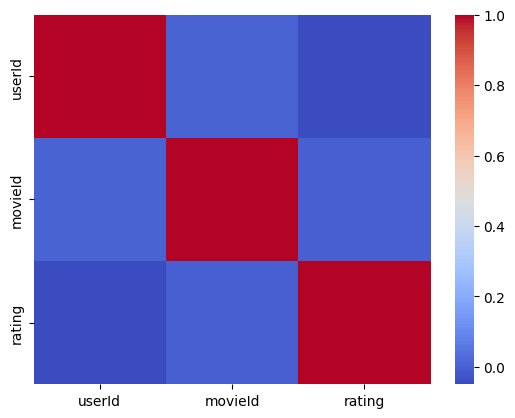

In [55]:
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm")

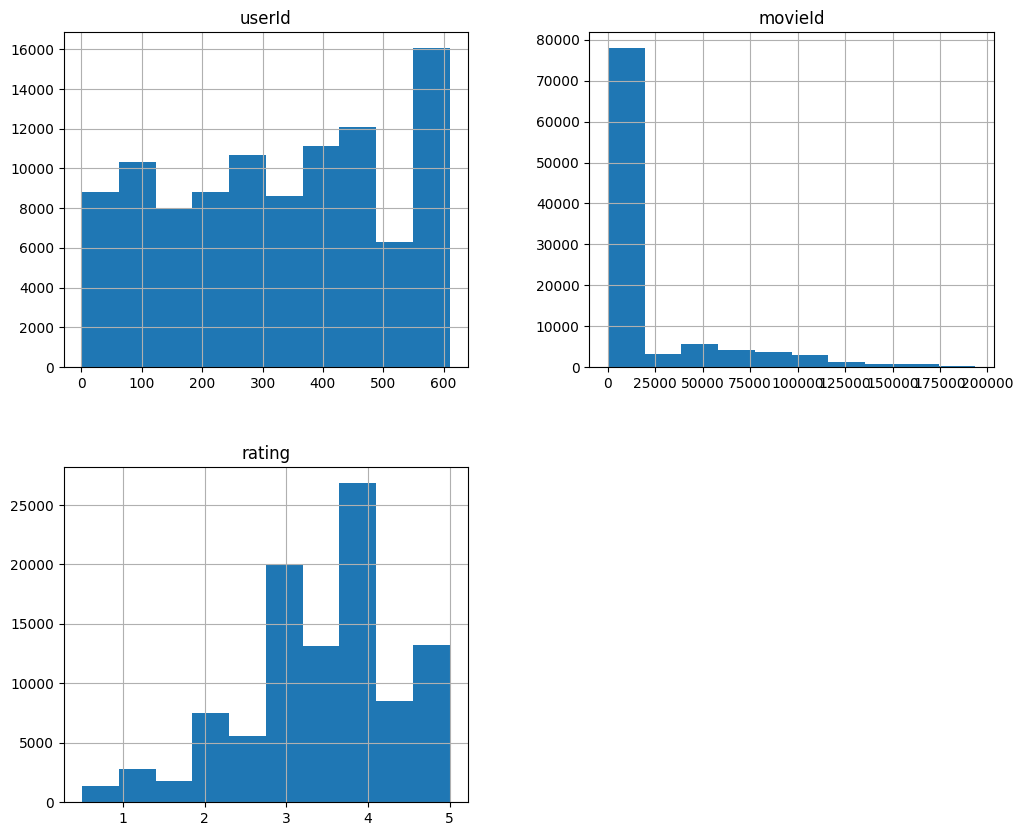

In [56]:
df.hist(figsize=(12, 10))
plt.show()

In [57]:
corr_mat = df.corr(numeric_only=True)

In [58]:
print(corr_mat.iloc[:5, :5])

           userId   movieId    rating
userId   1.000000  0.006773 -0.049348
movieId  0.006773  1.000000 -0.004061
rating  -0.049348 -0.004061  1.000000


In [59]:
movie_stats = df.groupby(["movieId", "title"]).rating.agg(["mean", "count"]).reset_index()
movie_stats.columns = ["movieId", "title", "avg_rating", "num_ratings"]
top_movies = movie_stats.query("num_ratings >= 50").nlargest(10, "avg_rating")
print("\nTOP 10 MOVIES:\n", top_movies)


TOP 10 MOVIES:
       movieId                                              title  avg_rating  \
277       318                   Shawshank Redemption, The (1994)    4.429022   
659       858                              Godfather, The (1972)    4.289062   
2224     2959                                  Fight Club (1999)    4.272936   
974      1276                              Cool Hand Luke (1967)    4.271930   
602       750  Dr. Strangelove or: How I Learned to Stop Worr...    4.268041   
686       904                                 Rear Window (1954)    4.261905   
921      1221                     Godfather: Part II, The (1974)    4.259690   
6298    48516                               Departed, The (2006)    4.252336   
913      1213                                  Goodfellas (1990)    4.250000   
694       912                                  Casablanca (1942)    4.240000   

      num_ratings  
277           317  
659           192  
2224          218  
974            57  
60

In [60]:
df["genres"] = df["genres"].str.split("|")
genre_stats = df.explode("genres").groupby("genres").rating.agg(["mean", "count"]).sort_values("mean", ascending=False)
print("\nTOP GENRES:\n", genre_stats.head(10))


TOP GENRES:
                  mean  count
genres                      
Film-Noir    3.920115    870
War          3.808294   4859
Documentary  3.797785   1219
Crime        3.658294  16681
Drama        3.656184  41928
Mystery      3.632460   7674
Animation    3.629937   6988
IMAX         3.618335   4145
Western      3.583938   1930
Musical      3.563678   4138


In [61]:
top_movie_id = top_movies.iloc[0]["movieId"]
fans = df[df["movieId"] == top_movie_id].query("rating >= 4.0")["userId"]
recs = (
    df[df["userId"].isin(fans)]
    .query("movieId != @top_movie_id")
    .groupby(["movieId", "title"]).rating.agg(["mean", "count"])
    .reset_index()
    .query("mean >= 4.0 and count >= 10")
    .nlargest(10, "mean")
)
print("RECOMMENDATIONS:\n", recs)

RECOMMENDATIONS:
       movieId                                              title      mean  \
6443    92259                                Intouchables (2011)  4.583333   
538       720  Wallace & Gromit: The Best of Aardman Animatio...  4.571429   
806      1178                              Paths of Glory (1957)  4.500000   
6790   106918            Secret Life of Walter Mitty, The (2013)  4.454545   
775      1104                   Streetcar Named Desire, A (1951)  4.428571   
894      1272                                      Patton (1970)  4.428571   
1981     2959                                  Fight Club (1999)  4.425373   
426       527                            Schindler's List (1993)  4.418367   
2269     3435                            Double Indemnity (1944)  4.416667   
606       858                              Godfather, The (1972)  4.415929   

      count  
6443     18  
538      14  
806      11  
6790     11  
775      14  
894      21  
1981    134  
426     147

In [62]:

df["is_good"] = (df["rating"] >= 4.0).astype(int)


genre_features = df["genres"].str.get_dummies(sep="|").astype(int)


user_stats = df.groupby("userId").rating.agg(["mean", "count", "std"]).reset_index()
user_stats.columns = ["userId", "user_avg_rating", "user_rating_count", "user_rating_std"]
df = df.merge(user_stats, on="userId")


movie_stats = df.groupby("movieId").rating.agg(["mean", "count"]).reset_index()
movie_stats.columns = ["movieId", "movie_avg_rating", "movie_rating_count"]
df = df.merge(movie_stats, on="movieId")


feature_cols = [col for col in df.columns if col.startswith(('Action', 'Comedy')) or col in 
                ["user_avg_rating", "user_rating_count", "user_rating_std", 
                 "movie_avg_rating", "movie_rating_count"]]
X = df[feature_cols].fillna(0)
y = df["is_good"]

print("FAST Features:", X.shape)  
X.head()



FAST Features: (100836, 5)


,user_avg_rating,user_rating_count,user_rating_std,movie_avg_rating,movie_rating_count
0,4.366379,232,0.800048,3.920930,215
1,4.366379,232,0.800048,3.259615,52
2,4.366379,232,0.800048,3.946078,102
3,4.366379,232,0.800048,3.975369,203
4,4.366379,232,0.800048,4.237745,204


In [63]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print("Train shape:", X_train_s.shape) 




Train shape: (80668, 5)


In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_s, y_train)
lr_pred = lr.predict(X_test_s)
lr_acc = accuracy_score(y_test, lr_pred)
print(f"Logistic Accuracy: {lr_acc:.4f}")
print(classification_report(y_test, lr_pred))


Logistic Accuracy: 0.7385
              precision    recall  f1-score   support

           0       0.76      0.73      0.74     10452
           1       0.72      0.75      0.73      9716

    accuracy                           0.74     20168
   macro avg       0.74      0.74      0.74     20168
weighted avg       0.74      0.74      0.74     20168



In [65]:
from sklearn.svm import SVC
svm = SVC(kernel="rbf", random_state=42)
svm.fit(X_train_s, y_train)
svm_pred = svm.predict(X_test_s)
svm_acc = accuracy_score(y_test, svm_pred)
print(f"SVM Accuracy: {svm_acc:.4f}")
print(classification_report(y_test, svm_pred))


SVM Accuracy: 0.7445
              precision    recall  f1-score   support

           0       0.76      0.73      0.75     10452
           1       0.72      0.76      0.74      9716

    accuracy                           0.74     20168
   macro avg       0.74      0.74      0.74     20168
weighted avg       0.75      0.74      0.74     20168



In [66]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)
knn_pred = knn.predict(X_test_s)
knn_acc = accuracy_score(y_test, knn_pred)
print(f"KNN Accuracy: {knn_acc:.4f}")
print(classification_report(y_test, knn_pred))


KNN Accuracy: 0.7194
              precision    recall  f1-score   support

           0       0.73      0.72      0.73     10452
           1       0.70      0.72      0.71      9716

    accuracy                           0.72     20168
   macro avg       0.72      0.72      0.72     20168
weighted avg       0.72      0.72      0.72     20168



In [67]:
comparison = pd.DataFrame({
    "Method": ["Logistic", "SVM", "KNN"],
    "Accuracy": [lr_acc, svm_acc, knn_acc]
}).sort_values("Accuracy", ascending=False)
print(" FINAL RANKING")
print(comparison)
comparison.to_csv("comparison_results.csv")


 FINAL RANKING
     Method  Accuracy
1       SVM  0.744546
0  Logistic  0.738497
2       KNN  0.719357


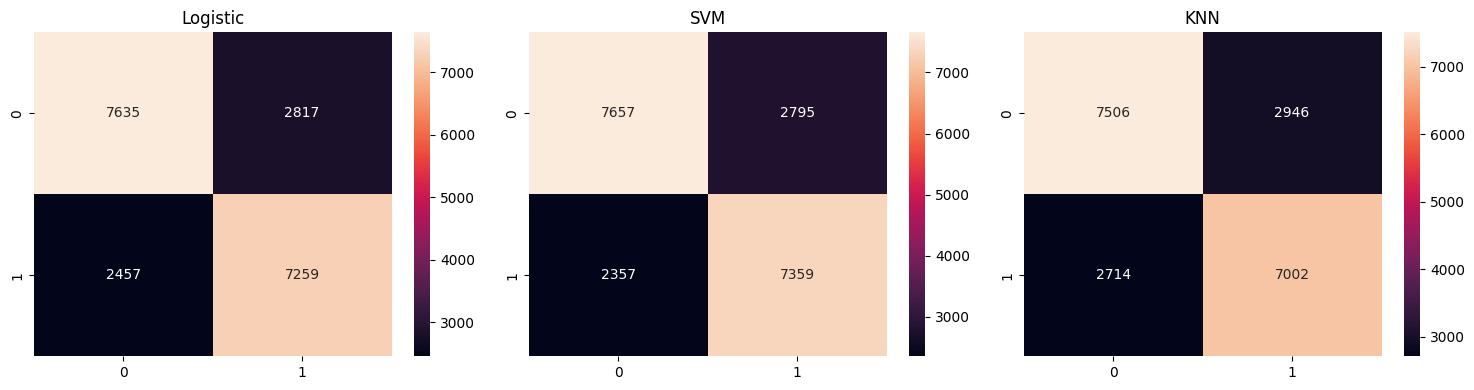

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', ax=axes[0])
axes[0].set_title('Logistic')
sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt='d', ax=axes[1])
axes[1].set_title('SVM')
sns.heatmap(confusion_matrix(y_test, knn_pred), annot=True, fmt='d', ax=axes[2])
axes[2].set_title('KNN')
plt.tight_layout()
plt.savefig("confusion_matrices.png")
plt.show()
